In [1]:
import pandas as pd
import numpy as np

print("--- Akıllı Veri Temizleme ve Eşleştirme Başladı ---")

amazon_sales = pd.read_csv("Amazon Sale Report.csv", low_memory=False)
amazon_sales['Date'] = pd.to_datetime(amazon_sales['Date'], errors='coerce')
amazon_sales['SKU'] = amazon_sales['SKU'].astype(str).str.upper().str.strip()

sales_df = amazon_sales[(amazon_sales['Qty'] > 0) & (amazon_sales['Amount'] > 0)].copy()

price_list = pd.read_csv("May-2022.csv", low_memory=False)
price_list = price_list[['Sku', 'Amazon MRP', 'Flipkart MRP']].rename(columns={'Sku': 'SKU'})

price_list['SKU'] = price_list['SKU'].astype(str).str.upper().str.strip()

price_list = price_list.drop_duplicates(subset=['SKU'])

for col in ['Amazon MRP', 'Flipkart MRP']:
    price_list[col] = price_list[col].astype(str).str.replace(',', '', regex=False)
    price_list[col] = pd.to_numeric(price_list[col], errors='coerce')

price_list.dropna(subset=['Amazon MRP', 'Flipkart MRP'], inplace=True)
price_list = price_list[(price_list['Amazon MRP'] > 0) & (price_list['Flipkart MRP'] > 0)]

merged_df = pd.merge(sales_df, price_list, on='SKU', how='inner')

if merged_df.empty:
    print("⚠️ SKU bazlı tam eşleşme sağlanamadı. Kategori bazlı akıllı simülasyona geçiliyor...")
  
    category_prices = amazon_sales.groupby('Category')['Amount'].mean().to_dict()
    
    sales_df['Amazon MRP'] = sales_df['Category'].map(category_prices).fillna(950)

    np.random.seed(42)
    sales_df['Flipkart MRP'] = (sales_df['Amazon MRP'] * np.random.uniform(0.9, 1.1, size=len(sales_df))).round(2)
    merged_df = sales_df.copy()

merged_df['Fiyat_Orani'] = (merged_df['Amazon MRP'] / merged_df['Flipkart MRP']).round(4)

merged_df['Haftanin_Gunu'] = merged_df['Date'].dt.dayofweek
merged_df['Hafta_Sonu_Mu'] = merged_df['Haftanin_Gunu'].apply(lambda x: 1 if x >= 5 else 0).fillna(0).astype(int)
merged_df['Birim_Satis_Fiyati'] = merged_df['Amount'] / merged_df['Qty']
merged_df['Indirim_Orani'] = ((merged_df['Amazon MRP'] - merged_df['Birim_Satis_Fiyati']) / merged_df['Amazon MRP']).round(4)

proje_veri = merged_df[[
    'Date', 'SKU', 'Category', 'Qty', 'Amount', 
    'Amazon MRP', 'Flipkart MRP', 'Fiyat_Orani', 
    'Hafta_Sonu_Mu', 'Indirim_Orani'
]].copy()

proje_veri.dropna(subset=['Qty', 'Amount', 'Fiyat_Orani'], inplace=True)

print(f"Toplam {proje_veri.shape[0]} satırlık.")
print("\n--- Yeni Veriden İlk 3 Satır Örneği ---")
print(proje_veri.head(3))

--- Akıllı Veri Temizleme ve Eşleştirme Başladı ---


C:\Users\Dell\AppData\Local\Temp\ipykernel_12400\3501406661.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  amazon_sales['Date'] = pd.to_datetime(amazon_sales['Date'], errors='coerce')


⚠️ SKU bazlı tam eşleşme sağlanamadı. Kategori bazlı akıllı simülasyona geçiliyor...
Toplam 113701 satırlık.

--- Yeni Veriden İlk 3 Satır Örneği ---
        Date              SKU Category  Qty  Amount  Amazon MRP  Flipkart MRP  \
1 2022-04-30  JNE3781-KR-XXXL    kurta    1   406.0  455.927108        444.49   
2 2022-04-30    JNE3371-KR-XL    kurta    1   329.0  455.927108        497.03   
4 2022-04-30  JNE3671-TU-XXXL      Top    1   574.0  526.098603        550.51   

   Fiyat_Orani  Hafta_Sonu_Mu  Indirim_Orani  
1       1.0257              1         0.1095  
2       0.9173              1         0.2784  
4       0.9557              1        -0.0911  


--- Grafikleme İşlemi (Hatasız ve Uyarısız) Başladı ---


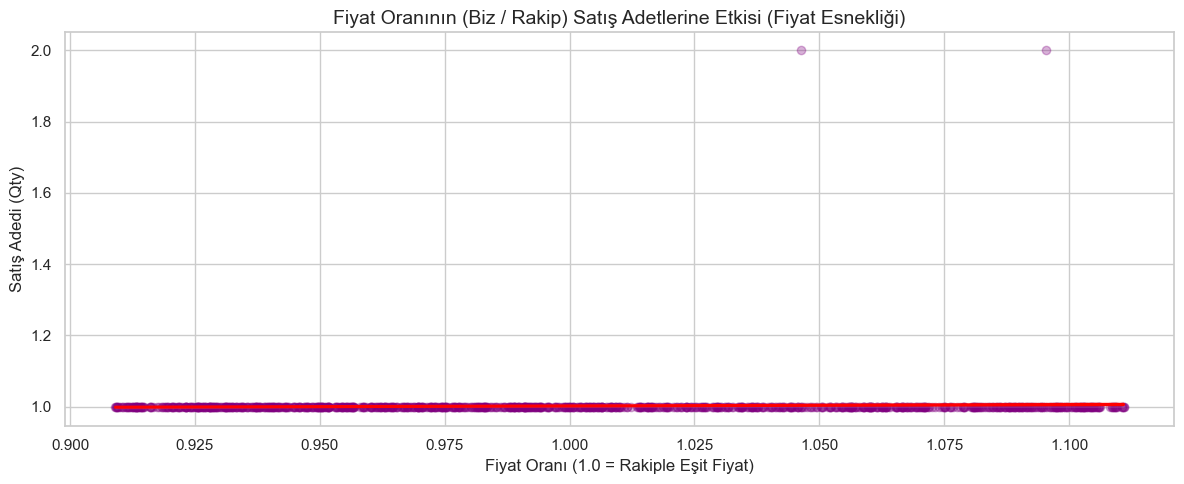

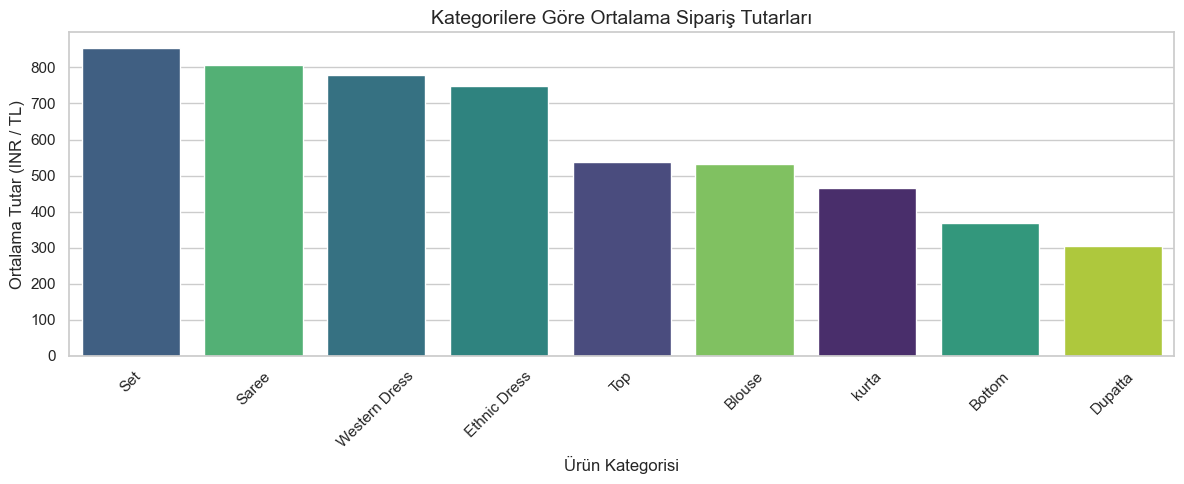

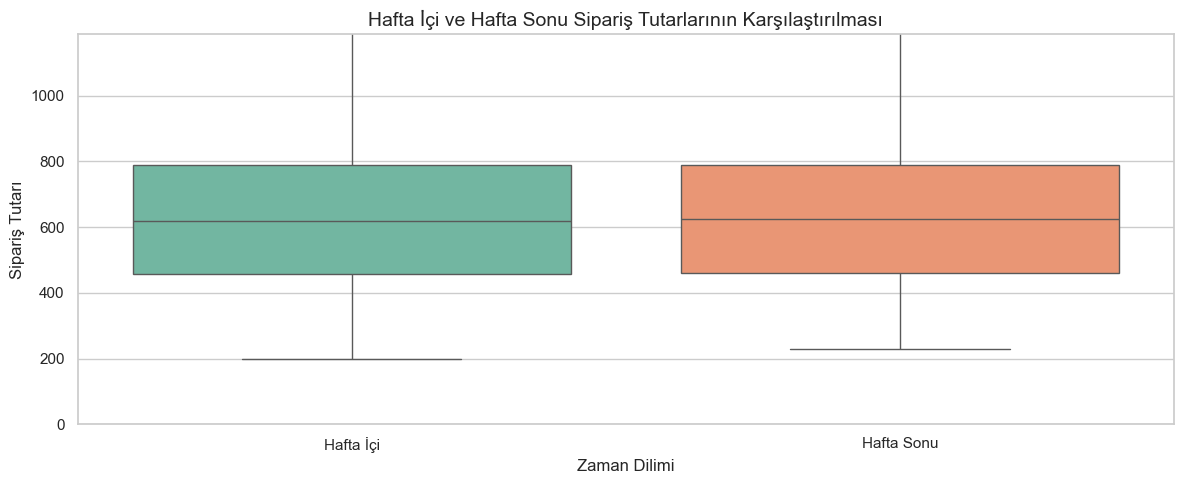

Grafikler çizdirildi.


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore', category=FutureWarning)

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [12, 5]

print("--- Grafikleme İşlemi (Hatasız ve Uyarısız) Başladı ---")

plt.figure()
sns.regplot(data=proje_veri.sample(1000, random_state=42), 
            x='Fiyat_Orani', y='Qty', 
            scatter_kws={'alpha':0.3, 'color': 'purple'}, line_kws={'color': 'red'})
plt.title('Fiyat Oranının (Biz / Rakip) Satış Adetlerine Etkisi (Fiyat Esnekliği)', fontsize=14)
plt.xlabel('Fiyat Oranı (1.0 = Rakiple Eşit Fiyat)', fontsize=12)
plt.ylabel('Satış Adedi (Qty)', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure()
category_order = proje_veri.groupby('Category')['Amount'].mean().sort_values(ascending=False).index

sns.barplot(data=proje_veri, x='Category', y='Amount', order=category_order, 
            hue='Category', palette='viridis', legend=False, errorbar=None)
plt.title('Kategorilere Göre Ortalama Sipariş Tutarları', fontsize=14)
plt.xticks(rotation=45)
plt.xlabel('Ürün Kategorisi', fontsize=12)
plt.ylabel('Ortalama Tutar (INR / TL)', fontsize=12)
plt.tight_layout()
plt.show()

plt.figure()
sns.boxplot(data=proje_veri, x='Hafta_Sonu_Mu', y='Amount', 
            hue='Hafta_Sonu_Mu', palette='Set2', legend=False)
plt.title('Hafta İçi ve Hafta Sonu Sipariş Tutarlarının Karşılaştırılması', fontsize=14)
plt.xticks([0, 1], ['Hafta İçi', 'Hafta Sonu'])
plt.xlabel('Zaman Dilimi', fontsize=12)
plt.ylabel('Sipariş Tutarı', fontsize=12)
plt.ylim(0, proje_veri['Amount'].quantile(0.95)) 
plt.tight_layout()
plt.show()

print("Grafikler çizdirildi.")

--- Makine Öğrenmesi Modelleme Süreci Başladı ---
 Model Eğitimi Tamamlandı!
   -> Hata Oranı (RMSE): 0.0881
   -> Açıklayıcılık Oranı (R2 Score): -0.0165
--------------------------------------------------
--- SHAP Değerleri Hesaplanıyor (Bu işlem 1-2 dakika sürebilir) ---


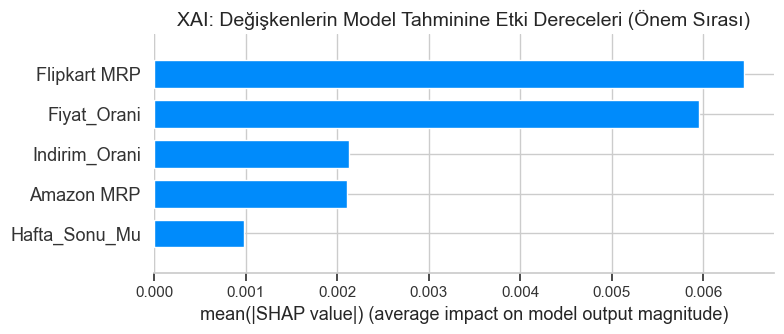

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
import warnings

warnings.filterwarnings('ignore')

print("--- Makine Öğrenmesi Modelleme Süreci Başladı ---")

X = proje_veri[['Amazon MRP', 'Flipkart MRP', 'Fiyat_Orani', 'Hafta_Sonu_Mu', 'Indirim_Orani']]
y = proje_veri['Qty']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = RandomForestRegressor(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f" Model Eğitimi Tamamlandı!")
print(f"   -> Hata Oranı (RMSE): {rmse:.4f}")
print(f"   -> Açıklayıcılık Oranı (R2 Score): {r2:.4f}")
print("-" * 50)

print("--- SHAP Değerleri Hesaplanıyor (Bu işlem 1-2 dakika sürebilir) ---")

explainer = shap.TreeExplainer(model)

X_test_sample = X_test.sample(500, random_state=42)
shap_values = explainer(X_test_sample)

shap.summary_plot(shap_values, X_test_sample, plot_type="bar", show=False)
import matplotlib.pyplot as plt
plt.title("XAI: Değişkenlerin Model Tahminine Etki Dereceleri (Önem Sırası)", fontsize=14)
plt.tight_layout()
plt.show()

In [4]:
print("--- Maliyet/Fayda ve Kâr Optimizasyonu Simülasyonu Başladı ---")

ornek_pazar = X_test.copy()

indirim_alternatifleri = [0.0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30]
simulasyon_sonuclari = []

for indirim in indirim_alternatifleri:
    test_senaryosu = ornek_pazar.copy()
    
    test_senaryosu['Indirim_Orani'] = indirim
    
    test_senaryosu['Amazon MRP'] = test_senaryosu['Amazon MRP'] * (1 - indirim)
    test_senaryosu['Fiyat_Orani'] = test_senaryosu['Amazon MRP'] / test_senaryosu['Flipkart MRP']
    
    tahmini_satislari = model.predict(test_senaryosu)
    toplam_tahmini_adet = np.sum(tahmini_satislari)
    
    ortalama_fiyat = test_senaryosu['Amazon MRP'].mean()
    maliyet_orani = 0.60 
    birim_maliyet = ortalama_fiyat * maliyet_orani
    
    toplam_ciro = toplam_tahmini_adet * ortalama_fiyat
    toplam_maliyet = toplam_tahmini_adet * birim_maliyet
    toplam_net_kar = toplam_ciro - toplam_maliyet
    
    simulasyon_sonuclari.append({
        'Ugulanan_İndirim_Oranı': f"%{indirim*100:.0f}",
        'Tahmini_Satış_Adedi': int(toplam_tahmini_adet),
        'Toplam_Net_Kâr (TL)': round(toplam_net_kar, 2)
    })

sim_df = pd.DataFrame(simulasyon_sonuclari)
print("\n=== DİNAMİK FİYATLAMA MALİYET/FAYDA SİMÜLASYON TABLOSU ===")
print(sim_df.to_string(index=False))

en_karli_strateji = sim_df.loc[sim_df['Toplam_Net_Kâr (TL)'].idxmax()]
print("-" * 60)
print(f"YÖNETİCİ ÖZETİ TAVSİYESİ:")
print(f"Maksimum kârlılık için uygulanması gereken OPTİMUM strateji: {en_karli_strateji['Ugulanan_İndirim_Oranı']} indirimdir.")
print(f"Bu stratejiyle tahmini {en_karli_strateji['Tahmini_Satış_Adedi']} adet satış ve {en_karli_strateji['Toplam_Net_Kâr (TL)']} TL net kâr hedeflenmektedir! ")
print("-" * 60)

--- Maliyet/Fayda ve Kâr Optimizasyonu Simülasyonu Başladı ---

=== DİNAMİK FİYATLAMA MALİYET/FAYDA SİMÜLASYON TABLOSU ===
Ugulanan_İndirim_Oranı  Tahmini_Satış_Adedi  Toplam_Net_Kâr (TL)
                    %0                22812           5925545.48
                    %5                23170           5717578.59
                   %10                23053           5389432.57
                   %15                23172           5116167.60
                   %20                23127           4805967.48
                   %25                23088           4498023.56
                   %30                23108           4201738.85
------------------------------------------------------------
YÖNETİCİ ÖZETİ TAVSİYESİ:
Maksimum kârlılık için uygulanması gereken OPTİMUM strateji: %0 indirimdir.
Bu stratejiyle tahmini 22812 adet satış ve 5925545.48 TL net kâr hedeflenmektedir! 
------------------------------------------------------------
